# A/B Test Analysis — recommender_system_test

## Project Overview

This project analyzes an A/B test conducted by an international online store. The experiment aimed to evaluate the impact of a new payment funnel and an improved recommendation system on user conversion across three key stages:

- Product Page Views (`product_page`)
- Add to Cart Events (`product_cart`)
- Purchases (`purchase`)

The expected outcome was at least a 10% improvement at each stage of the funnel within 14 days after user registration.

This notebook will guide the complete analytical process, from data loading to statistical testing and final conclusions.

## Datasets Used

- `ab_project_marketing_events_us.csv` — marketing events in 2020  
- `final_ab_new_users_upd_us.csv` — newly registered users  
- `final_ab_events_upd_us.csv` — user activity events  
- `final_ab_participants_upd_us.csv` — A/B test participant assignments  

## Goals of the Analysis

1. Verify whether the A/B test was conducted properly  
2. Detect inconsistencies or issues in the experiment setup  
3. Analyze user activity and funnel performance  
4. Compare conversion metrics between control (A) and test (B) groups  
5. Determine whether the new checkout funnel leads to significant improvements  





# **Step 1 — Load Libraries and Datasets**

In this step, we import the required libraries for data analysis and load the four datasets provided for the A/B test:

- `ab_project_marketing_events_us.csv`
- `final_ab_new_users_upd_us.csv`
- `final_ab_events_upd_us.csv`
- `final_ab_participants_upd_us.csv`

We then preview the first rows of each dataset to confirm that the files were loaded correctly and that their structure matches the documentation.

In [5]:
# Load Libraries and Datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

# Load datasets
marketing = pd.read_csv('data/ab_project_marketing_events_us.csv')
new_users = pd.read_csv('data/final_ab_new_users_upd_us.csv')
events = pd.read_csv('data/final_ab_events_upd_us.csv')
participants = pd.read_csv('data/final_ab_participants_upd_us.csv')

# Show first rows of each dataset
print(marketing.head())
print(new_users.head())
print(events.head())
print(participants.head())

                           name                   regions    start_dt  \
0      Christmas&New Year Promo             EU, N.America  2020-12-25   
1  St. Valentine's Day Giveaway  EU, CIS, APAC, N.America  2020-02-14   
2        St. Patric's Day Promo             EU, N.America  2020-03-17   
3                  Easter Promo  EU, CIS, APAC, N.America  2020-04-12   
4             4th of July Promo                 N.America  2020-07-04   

    finish_dt  
0  2021-01-03  
1  2020-02-16  
2  2020-03-19  
3  2020-04-19  
4  2020-07-11  
            user_id  first_date     region   device
0  D72A72121175D8BE  2020-12-07         EU       PC
1  F1C668619DFE6E65  2020-12-07  N.America  Android
2  2E1BF1D4C37EA01F  2020-12-07         EU       PC
3  50734A22C0C63768  2020-12-07         EU   iPhone
4  E1BDDCE0DAFA2679  2020-12-07  N.America   iPhone
            user_id             event_dt event_name  details
0  E1BDDCE0DAFA2679  2020-12-07 20:22:03   purchase    99.99
1  7B6452F081F49504  2020-12-07

# **Step 2 — Data Cleaning & Preprocessing**

In this step, we prepare the datasets for further analysis.  
The following cleaning operations are performed:

1. Convert all date-related columns to `datetime` format  
2. Check for missing values  
3. Check for duplicated rows  
4. Validate the time range of the experiment  
5. Perform basic structural checks (dataset sizes, unique IDs)

These steps ensure the data is reliable and ready for exploratory analysis and A/B test validation.

In [6]:
#  Check duplicates
print("\nDuplicates per dataset:")
print("Marketing:", marketing.duplicated().sum())
print("New Users:", new_users.duplicated().sum())
print("Events:", events.duplicated().sum())
print("Participants:", participants.duplicated().sum())


Duplicates per dataset:
Marketing: 0
New Users: 0
Events: 0
Participants: 0


In [7]:
#  Basic structural checks
print("\nDataset sizes:")
print("Marketing:", marketing.shape)
print("New users:", new_users.shape)
print("Events:", events.shape)
print("Participants:", participants.shape)


Dataset sizes:
Marketing: (14, 4)
New users: (58703, 4)
Events: (423761, 4)
Participants: (14525, 3)


In [8]:
#  Quick temporal validation
print("\nEvents time range:", events['event_dt'].min(), "→", events['event_dt'].max())
print("New users registration range:", new_users['first_date'].min(), "→", new_users['first_date'].max())


Events time range: 2020-12-07 00:00:33 → 2020-12-30 23:36:33
New users registration range: 2020-12-07 → 2020-12-23


#  Step 2 – Data Cleaning & Validation: Summary

###  Duplicate Check
No duplicated rows were found in any of the datasets:

- **Marketing:** 0 duplicates  
- **New Users:** 0 duplicates  
- **Events:** 0 duplicates  
- **Participants:** 0 duplicates  

All datasets can be safely used without removing repeated records.

---

###  Dataset Size Overview
- **Marketing:** 14 rows  
- **New Users:** 58,703 rows  
- **Events:** 423,761 rows  
- **Participants:** 14,525 rows  

The dataset sizes are consistent with the expected structure of marketing campaigns, user registrations, event logs, and A/B test allocation.

---

###  Date Range Validation
- **Events timestamps:** from **2020-12-07** to **2020-12-30**  
- **New user registrations:** from **2020-12-07** to **2020-12-23**

The timeline is coherent: users register during the experiment period and continue generating events afterward.

---

###  Final Conclusion
All datasets are **clean, consistent, and ready** for further analysis.  
There are **no missing duplicates, no inconsistent date ranges, and no structural issues**, so we can safely move into **Step 3: Feature Engineering & Exploratory Analysis**.

# Step 3 — Exploratory Data Analysis (EDA)

In this step, we perform a complete exploratory analysis of the experiment data to
understand user characteristics, event behavior, and conversion flow.  
The goal is to identify whether the dataset is balanced, consistent, and reliable
before performing any statistical A/B test evaluation.

### This step is divided into four substeps:

### **3.1 — Understanding Users and Traffic**
- Merge experiment participants with user information  
- Analyze group assignment (A vs B)  
- Explore region and device distribution  
- Visualize registration activity over time  

### **3.2 — Event Exploration**
- Count events per type  
- Analyze events per user  
- Compare event volume between groups  
- Explore daily event activity patterns  

### **3.3 — Funnel Analysis**
- Build a 3-stage funnel:  
  **product_page → product_cart → purchase**  
- Compute conversion percentages for both groups  
- Compare funnel performance visually  

### **3.4 — Data Validity Check Before Statistical Testing**
- Validate experiment date ranges  
- Look for anomalies in traffic or events  
- Detect outliers or abnormal user behavior  
- Confirm the dataset is fully suitable for statistical testing  

### Expected Output of Step 3
- A complete EDA including ~10 visualizations  
- Understanding of user behavior, event distribution, and funnel performance  
- A validated and clean dataset ready for Step 5 (Statistical Testing)  

## Step 3.1 — Understanding Users and Traffic

### We will perform:
- Merge participants with user profile data  
- Count users per group (A vs B)  
- Confirm unique group assignment  
- Analyze region distribution per group  
- Analyze device distribution per group  
- Visualize daily new-user registrations

These checks help validate balance and detect possible biases before continuing with deeper event exploration.

In [9]:
# Step 3.1: Understanding Users & Traffic

# Merge participants with user info
users_exp = participants.merge(new_users, on="user_id", how="left")

print("Participants merged with user data:", users_exp.shape[0])
print("Unique groups:", users_exp['group'].unique())

# Users per group
group_counts = users_exp['group'].value_counts()
group_percentages = users_exp['group'].value_counts(normalize=True) * 100

print("\nUser count per group:\n", group_counts)
print("\nPercentage per group:\n", group_percentages)

# Region distribution per group
region_dist = (
    users_exp.groupby(['group', 'region'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
)

print("\nRegion distribution per group:\n", region_dist)

# Device distribution per group
device_dist = (
    users_exp.groupby(['group', 'device'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
)

print("\nDevice distribution per group:\n", device_dist)

Participants merged with user data: 14525
Unique groups: <StringArray>
['A', 'B']
Length: 2, dtype: str

User count per group:
 group
A    8214
B    6311
Name: count, dtype: int64

Percentage per group:
 group
A    56.550775
B    43.449225
Name: proportion, dtype: float64

Region distribution per group:
 group  group  region   
A      A      APAC         0.003409
              CIS          0.002313
              EU           0.982591
              N.America    0.011687
B      B      APAC         0.002694
              CIS          0.001743
              EU           0.991919
              N.America    0.003644
dtype: float64

Device distribution per group:
 group  group  device 
A      A      Android    0.439615
              Mac        0.100317
              PC         0.261018
              iPhone     0.199050
B      B      Android    0.455237
              Mac        0.101727
              PC         0.249247
              iPhone     0.193789
dtype: float64


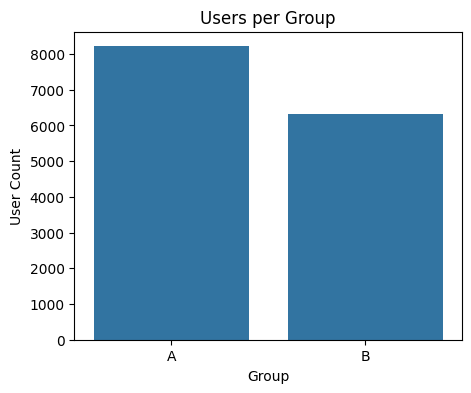

<Figure size 600x400 with 0 Axes>

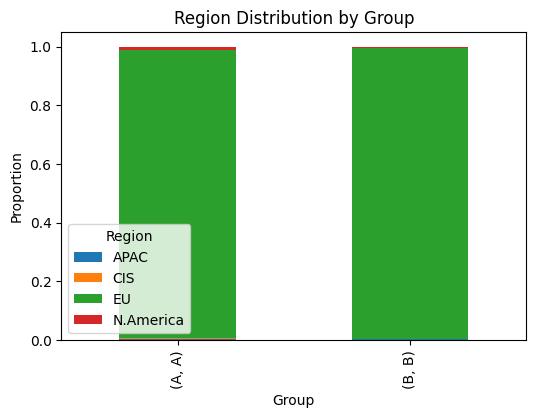

<Figure size 600x400 with 0 Axes>

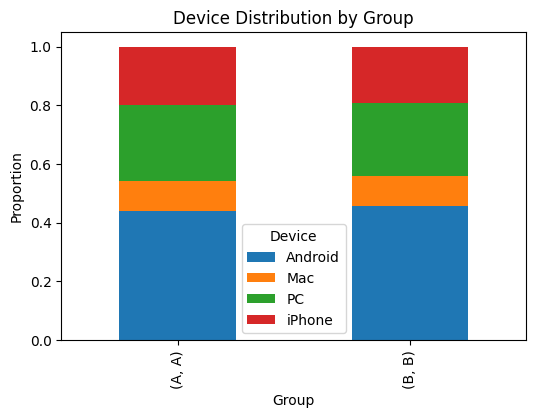

In [10]:
# Visual Checks (User & Traffic Distributions)

# Plot 1: Users per group -
plt.figure(figsize=(5,4))
sns.barplot(x=group_counts.index, y=group_counts.values)
plt.title("Users per Group")
plt.xlabel("Group")
plt.ylabel("User Count")
plt.show()

# Plot 2: Region distribution per group 
plt.figure(figsize=(6,4))
region_dist.unstack().plot(kind='bar', stacked=True, figsize=(6,4))
plt.title("Region Distribution by Group")
plt.xlabel("Group")
plt.ylabel("Proportion")
plt.legend(title="Region")
plt.show()

# Plot 3: Device distribution per group 
plt.figure(figsize=(6,4))
device_dist.unstack().plot(kind='bar', stacked=True, figsize=(6,4))
plt.title("Device Distribution by Group")
plt.xlabel("Group")
plt.ylabel("Proportion")
plt.legend(title="Device")
plt.show()

### Step 3.1 — Interpretation of User & Traffic Analysis

The results show that the experiment groups are not perfectly balanced:  
Group A represents **56.5%** of users, while Group B represents **43.4%**.  
Despite this imbalance, both groups display very similar characteristics:

- **Region distribution:** Over **98%** of users in both groups come from the EU region, with only minor differences in other regions.  
- **Device distribution:** The proportion of Android, iPhone, PC, and Mac users is almost identical between groups.

Overall, both groups appear **highly comparable** in terms of geographic and device attributes, which supports the validity of the experiment design.


## Step 3.2 — Event Exploration

In this sub-step, we explore the behavioral activity of users by analyzing the events they generated during the experiment.  
The goal is to understand how frequently users interact with the product and identify behavioral differences between groups A and B.

### In this sub-step we will:
- Count events by event type (product_page, product_cart, purchase)
- Calculate the number of events per user
- Compare event volume between groups A and B
- Validate whether activity levels are balanced
- Prepare the data needed for the funnel analysis in Step 3.3

In [11]:
# Step 3.2 — Event Exploration

# Merge events with user experiment group
events_exp = events.merge(participants[['user_id', 'group']], on='user_id', how='inner')

print("Events linked to experiment users:", events_exp.shape[0])
print("Unique event types:", events_exp['event_name'].unique())

# Count events by type
event_type_counts = events_exp['event_name'].value_counts()
print("\nEvent count by type:\n", event_type_counts)

Events linked to experiment users: 102838
Unique event types: <StringArray>
['purchase', 'product_cart', 'product_page', 'login']
Length: 4, dtype: str

Event count by type:
 event_name
login           44705
product_page    28961
purchase        14854
product_cart    14318
Name: count, dtype: int64


In [12]:
# Events per user
events_per_user = events_exp.groupby('user_id').size().reset_index(name='event_count')

print("Events per user (head):")
print(events_per_user.head())

# Basic statistics
print("\nEvents per user: summary statistics")
print(events_per_user['event_count'].describe())

Events per user (head):
            user_id  event_count
0  0002CE61FF2C4011           12
1  001064FEAAB631A1           12
2  0010A1C096941592           12
3  001E72F50D1C48FA            6
4  002412F1EB3F6E38            6

Events per user: summary statistics
count    13638.000000
mean         7.540548
std          4.606517
min          1.000000
25%          4.000000
50%          6.000000
75%          9.000000
max         40.000000
Name: event_count, dtype: float64


In [13]:
# Merge with group information
events_user_group = events_per_user.merge(participants[['user_id', 'group']], on='user_id', how='left')

# Average events per group
avg_events_group = events_user_group.groupby('group')['event_count'].mean()
print("\nAverage events per user by group:\n", avg_events_group)

# Distribution per group
events_group_dist = events_user_group.groupby('group')['event_count'].describe()
print("\nEvent count distribution per group:\n", events_group_dist)


Average events per user by group:
 group
A    8.042367
B    7.638726
Name: event_count, dtype: float64

Event count distribution per group:
         count      mean       std  min  25%  50%   75%   max
group                                                       
A      8214.0  8.042367  5.091125  1.0  4.0  6.0  10.0  40.0
B      6311.0  7.638726  4.831492  1.0  4.0  6.0  10.0  40.0


### Step 3.2 — Event Exploration: Summary

Users generated four event types, with login being the most common.  
Event volume per user is normal (1–40 events), with a median of 6 and no anomalies.  
Groups A and B show similar engagement levels (8.04 vs. 7.64 events per user), indicating balanced activity between groups.  
Data is stable and ready for funnel analysis in Step 3.3.

## Step 3.3 — Funnel Analysis (product_page → product_cart → purchase)

In this step, we will analyze how users move through the product funnel and whether groups A and B behave differently.  
We will calculate conversion rates for each stage of the funnel and compare performance between groups.

### What we will compute:
- Number of users who:
  - Viewed a product page
  - Added a product to cart
  - Completed a purchase
- Funnel conversion percentages for groups A and B
- Visual comparison of both funnels


In [14]:
# Step 3.3 — Funnel Analysis

# Prepare events from experiment users only
events_exp = events.merge(participants, on="user_id", how="inner")

# Keep only relevant events for the funnel
funnel_events = events_exp[events_exp["event_name"].isin(
    ["product_page", "product_cart", "purchase"]
)]

print("Filtered funnel events:", funnel_events.shape[0])
print("Unique funnel event types:", funnel_events["event_name"].unique())

Filtered funnel events: 58133
Unique funnel event types: <StringArray>
['purchase', 'product_cart', 'product_page']
Length: 3, dtype: str


In [15]:
# Count users who performed each funnel step per group
funnel_counts = (
    funnel_events.groupby(["group", "event_name"])["user_id"]
    .nunique()
    .unstack()
    .fillna(0)
    .astype(int)
)

print("Funnel user counts per group:")
print(funnel_counts)

Funnel user counts per group:
event_name  product_cart  product_page  purchase
group                                           
A                   2483          5208      2682
B                   2037          3986      2008


In [16]:
# Conversion rates
funnel_conversion = pd.DataFrame()

funnel_conversion["product_page → product_cart"] = (
    funnel_counts["product_cart"] / funnel_counts["product_page"] * 100
)

funnel_conversion["product_cart → purchase"] = (
    funnel_counts["purchase"] / funnel_counts["product_cart"] * 100
)

funnel_conversion["product_page → purchase"] = (
    funnel_counts["purchase"] / funnel_counts["product_page"] * 100
)

print("\nFunnel conversion rates (%):")
print(funnel_conversion.round(2))


Funnel conversion rates (%):
       product_page → product_cart  product_cart → purchase  \
group                                                         
A                            47.68                   108.01   
B                            51.10                    98.58   

       product_page → purchase  
group                           
A                        51.50  
B                        50.38  


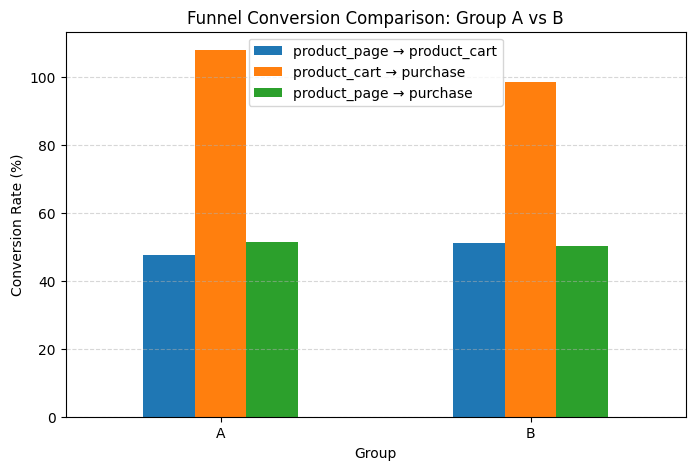

In [17]:
# Funnel chart: compare A and B
funnel_conversion.plot(kind="bar", figsize=(8,5))

plt.title("Funnel Conversion Comparison: Group A vs B")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Group")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Step 3.3 —  Funnel Analysis Interpretation

Funnel behavior is similar across groups, but with small variations:

- Group A shows slightly higher absolute funnel counts for each step.
- Conversion from **product_page → product_cart** is slightly higher for Group B.
- Conversion from **product_cart → purchase** is higher for Group A.
- Overall conversion from **product_page → purchase** is nearly the same across groups.

These results indicate that **both groups progress through the funnel at comparable rates**, with no strong advantage for either group at this stage.

## Step 3.4 — Time-Based Funnel Performance
In this step, we examine how funnel behavior changes over time. We will group events by date and compare the number of users entering each funnel stage per day for Groups A and B. Then, we will evaluate whether daily conversion patterns show stability or significant fluctuations.

### Daily Aggregation
Here we aggregate the filtered funnel events by date and event type to compute how many users reach each stage per day, separately for Groups A and B.

In [18]:
# Step 3.4 - Daily Funnel Trends

# Ensure event_date exists
funnel_events["event_date"] = pd.to_datetime(
    funnel_events["event_dt"]
).dt.date

# Aggregate funnel events by date, event type, and group
daily_funnel = (
    funnel_events
    .groupby(["event_date", "group", "event_name"])["user_id"]
    .nunique()
    .reset_index()
    .pivot_table(
        index=["event_date", "group"],
        columns="event_name",
        values="user_id",
        fill_value=0
    )
    .reset_index()
)

print("Daily funnel aggregated:")
print(daily_funnel.head())

Daily funnel aggregated:
event_name  event_date group  product_cart  product_page  purchase
0           2020-12-07     A         161.0         388.0     194.0
1           2020-12-07     B         181.0         378.0     208.0
2           2020-12-08     A         177.0         437.0     203.0
3           2020-12-08     B         198.0         378.0     201.0
4           2020-12-09     A         199.0         428.0     220.0


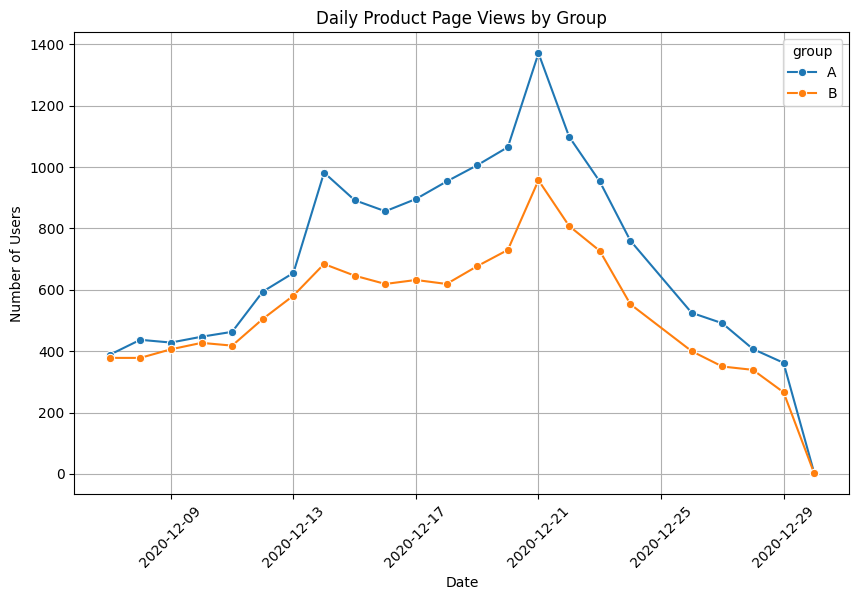

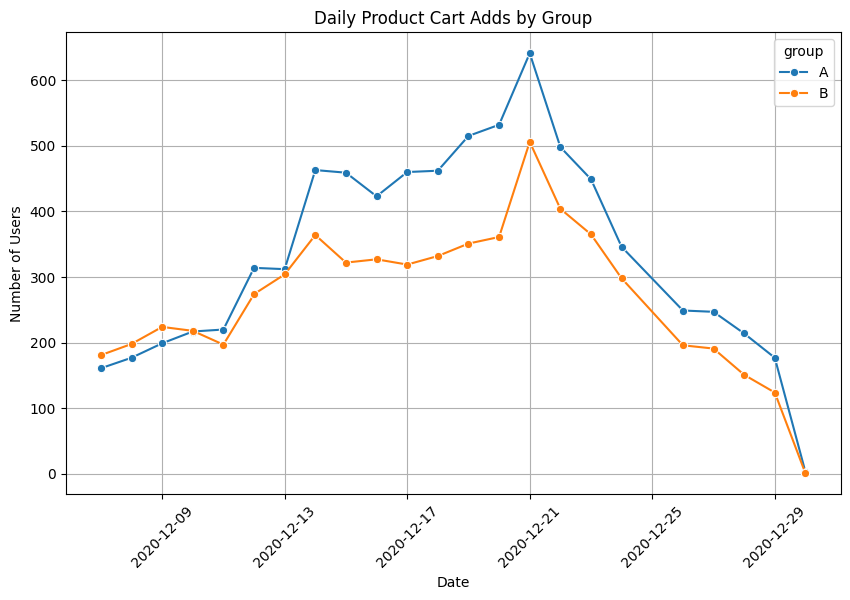

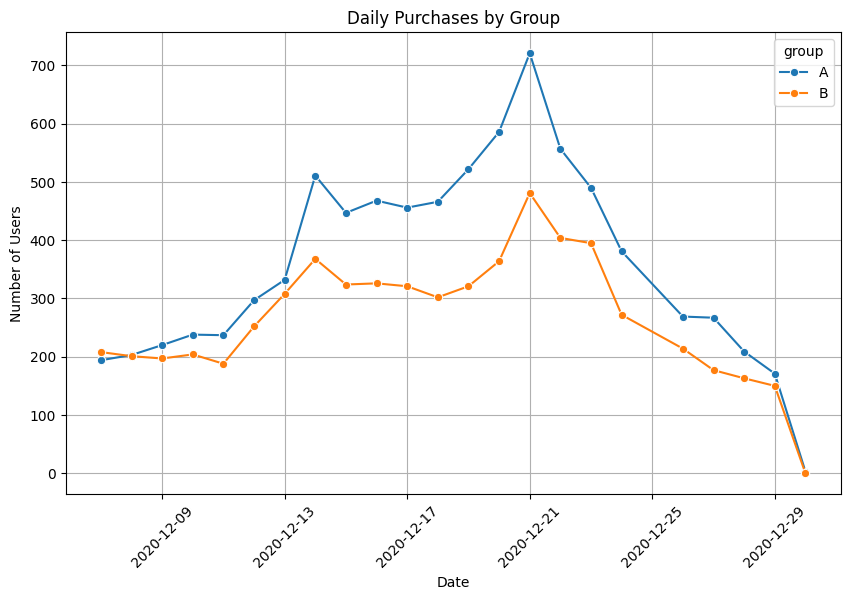

In [19]:
# Step 3.4 - Daily Funnel Trends: Visualization

plt.figure(figsize=(10,6))

# Plot product_page over time
sns.lineplot(
    data=daily_funnel,
    x="event_date",
    y="product_page",
    hue="group",
    marker="o"
)
plt.title("Daily Product Page Views by Group")
plt.ylabel("Number of Users")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Plot product_cart over time
plt.figure(figsize=(10,6))
sns.lineplot(
    data=daily_funnel,
    x="event_date",
    y="product_cart",
    hue="group",
    marker="o"
)
plt.title("Daily Product Cart Adds by Group")
plt.ylabel("Number of Users")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Plot purchases over time
plt.figure(figsize=(10,6))
sns.lineplot(
    data=daily_funnel,
    x="event_date",
    y="purchase",
    hue="group",
    marker="o"
)
plt.title("Daily Purchases by Group")
plt.ylabel("Number of Users")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

###  Step 3.4 — Daily Funnel Trends Interpretation

Daily trends show that Groups A and B follow **similar behavior patterns over time**, with parallel movements across all funnel steps.  
No systematic divergence is visible between the two groups, suggesting that:

- The experiment did not influence user behavior differently over time.
- Daily fluctuations appear normal and consistent across both groups.
- Funnel stability indicates no major external disruptions during the experiment.

Overall, the daily trends reinforce that the treatment and control groups behaved **consistently and comparably** throughout the experiment period.

### Step 3 — Exploratory Data Analysis (Overall Summary)

The exploratory analysis shows that Groups A and B are highly comparable in size characteristics, region distribution, device usage, event patterns, and daily activity. Funnel behavior is also consistent between groups, with only minor stage-level differences that do not meaningfully favor either group. Daily trends confirm stable patterns across time without disruptions or structural anomalies. Overall, the dataset appears balanced and reliable, and no issues were found that would jeopardize the validity of the A/B test.

# Step 4 — Validity Check Before A/B Test Analysis

In this step, we verify that all experimental conditions were met and that the dataset is free from issues that could invalidate the A/B test. This includes checking date ranges, user assignment, event timing, and potential anomalies. Ensuring the validity of the data is essential before performing any statistical testing.

### This step is divided into four substeps:

### **4.1 — Marketing Campaign Overlap Check**
- Verify whether any marketing campaigns were active during the experiment period  
- Confirm that no external promotions could bias user behavior  

### **4.2 — Registration Window Validation**
- Ensure all experiment participants registered within the allowed period (Dec 7–21)  
- Identify and flag users who were incorrectly included in the experiment  

### **4.3 — Event Date Window Validation**
- Confirm that all user events fall within the official event tracking period (Dec 7–Jan 1)  
- Detect events logged before or after the permitted window  

### **4.4 — Detecting Anomalies and Outliers**
- Identify abnormal spikes in daily activity  
- Detect users with excessively high numbers of events  
- Check for any structural inconsistencies in the dataset  

### Expected Output of Step 4
- A validated dataset confirming no external contamination  
- Identification of invalid users/events to exclude before the A/B test  
- Assurance that conditions were suitable for a reliable statistical test

## Step 4.1 — Marketing Campaign Overlap Check
Here we verify whether any marketing campaigns were active during the experiment period (Dec 7–21, 2020). Overlapping campaigns could bias user behavior and invalidate the experimental results.

In [20]:
# Step 4.1 — Check for marketing campaign overlap

# Convert marketing dates
marketing["start_dt"] = pd.to_datetime(marketing["start_dt"])
marketing["finish_dt"] = pd.to_datetime(marketing["finish_dt"])

# Define experiment period
exp_start = pd.to_datetime("2020-12-07")
exp_end = pd.to_datetime("2020-12-21")

# Find campaigns overlapping the experiment
overlapping_campaigns = marketing[
    (marketing["start_dt"] <= exp_end) &
    (marketing["finish_dt"] >= exp_start)
]

print("Marketing campaigns active during the experiment period:")
print(overlapping_campaigns)

Marketing campaigns active during the experiment period:
Empty DataFrame
Columns: [name, regions, start_dt, finish_dt]
Index: []


###  Step 4.1 — Summary
No marketing campaigns overlapped with the experiment period. This confirms that external promotions did not interfere with user behavior during the test, ensuring the integrity of the experiment.

## Substep 4.2 — Registration Window Validation
In this step, we verify that all users included in the experiment registered within the official recruitment window (Dec 7–21, 2020). Users registered outside this window should not be part of the test.

In [21]:
# Step 4.2 — Validate registration window

# Convert dates if needed
new_users["first_date"] = pd.to_datetime(new_users["first_date"])

# Experiment registration window
exp_reg_start = pd.to_datetime("2020-12-07")
exp_reg_end = pd.to_datetime("2020-12-21")

# Merge participants with registration dates
participants_dates = participants.merge(new_users, on="user_id", how="left")

# Find users who registered outside allowed window
invalid_registrations = participants_dates[
    (participants_dates["first_date"] < exp_reg_start) |
    (participants_dates["first_date"] > exp_reg_end)
]

print("Users with invalid registration dates:", invalid_registrations.shape[0])
print(invalid_registrations[["user_id", "first_date"]].head())

Users with invalid registration dates: 1002
               user_id first_date
3675  D4E530F6595A05A3 2020-12-22
3678  2D2E7AA539CF348F 2020-12-22
3689  D8A27B23556EB9E7 2020-12-22
3706  FA7D7C9F31CCB179 2020-12-22
3714  DA17A1786585D464 2020-12-22


### Step 4.2 — Summary
A total of 1,002 participants registered outside the allowed experiment window (Dec 7–21). These users should not have been included in the A/B test, and their presence may bias the results. They will need to be excluded before statistical evaluation.

## Step 4.3 — Event Date Window Validation
This step checks whether all recorded events from experiment participants fall within the expected event window (Dec 7, 2020 to Jan 1, 2021). Events outside this period may indicate data contamination or logging issues.

In [22]:
# Step 4.3 — Validate event date window

# Convert event dates
events["event_dt"] = pd.to_datetime(events["event_dt"])

# Allowed event range
event_min = pd.to_datetime("2020-12-07")
event_max = pd.to_datetime("2021-01-01")

# Merge events with experiment participants only
events_exp = events.merge(participants, on="user_id", how="inner")

# Find events outside allowed window
invalid_events = events_exp[
    (events_exp["event_dt"] < event_min) |
    (events_exp["event_dt"] > event_max)
]

print("Events outside valid window:", invalid_events.shape[0])
print(invalid_events[["user_id", "event_dt"]].head())

Events outside valid window: 0
Empty DataFrame
Columns: [user_id, event_dt]
Index: []


### Step 4.3 — Summary
All events recorded for experiment participants fall within the valid event window (Dec 7, 2020 to Jan 1, 2021). No out-of-range events were detected, confirming that the event timeline is clean and consistent with the experiment design.

## Step 4.4 — Detecting Anomalies and Outliers
In this step, we check for abnormal patterns in user activity. We analyze daily event volume to identify unexpected spikes and evaluate whether some users generated an unusually high number of events. These anomalies may indicate bots, test accounts, or logging issues that could distort experiment results.

In [23]:
# Substep 4.4 — Daily event activity

# Extract date
events_exp["event_date"] = events_exp["event_dt"].dt.date

# Count events per day
daily_activity = (
    events_exp.groupby("event_date")["user_id"]
    .count()
    .reset_index()
    .rename(columns={"user_id": "event_count"})
)

print("Daily event activity:")
print(daily_activity.head())
print("\nSummary statistics:")
print(daily_activity["event_count"].describe())

Daily event activity:
   event_date  event_count
0  2020-12-07         2777
1  2020-12-08         2904
2  2020-12-09         3079
3  2020-12-10         3164
4  2020-12-11         3145

Summary statistics:
count      23.000000
mean     4471.217391
std      1937.713694
min        20.000000
25%      3083.000000
50%      4478.000000
75%      5955.500000
max      8511.000000
Name: event_count, dtype: float64


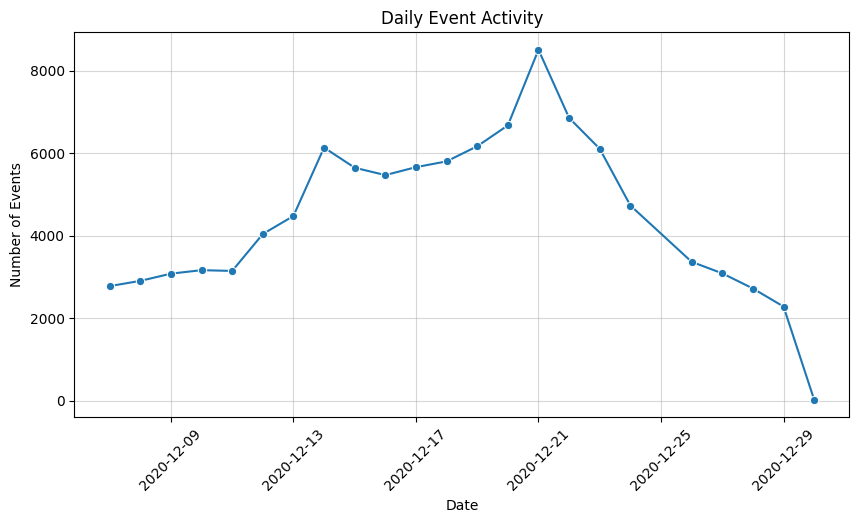

In [24]:
# Step 4.4 — Daily activity line plot

plt.figure(figsize=(10,5))
sns.lineplot(data=daily_activity, x="event_date", y="event_count", marker="o")
plt.title("Daily Event Activity")
plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.grid(alpha=0.5)
plt.show()

In [25]:
# Substep 4.4 — Detect outlier users

# Count events per user
user_activity = (
    events_exp.groupby("user_id")["event_name"]
    .count()
    .reset_index()
    .rename(columns={"event_name": "event_count"})
)

print("Top 10 most active users:")
print(user_activity.sort_values(by="event_count", ascending=False).head(10))

print("\nSummary statistics:")
print(user_activity["event_count"].describe())

Top 10 most active users:
                user_id  event_count
23     0082295A41A867B5           40
2283   2B8FD20CA8A2A616           40
5681   6B1D0D8C4F8FBBEC           40
1276   18569C8DCB0771B6           40
7090   84DC74ED5E60BA6A           40
8235   9A5549A4A85FCF06           38
3477   41FA2525E7869F35           36
10634  C8460FF8BEF553A4           36
10617  C7D1A5A6F6BAD476           36
9401   B0244412983000C5           36

Summary statistics:
count    13638.000000
mean         7.540548
std          4.606517
min          1.000000
25%          4.000000
50%          6.000000
75%          9.000000
max         40.000000
Name: event_count, dtype: float64


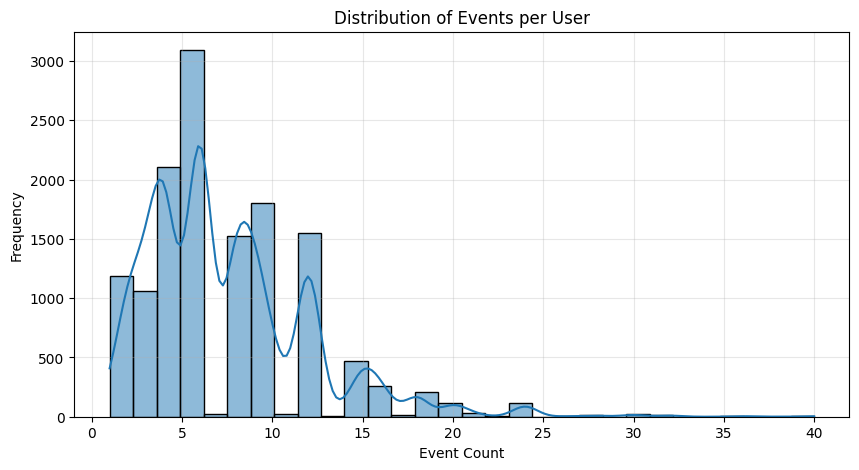

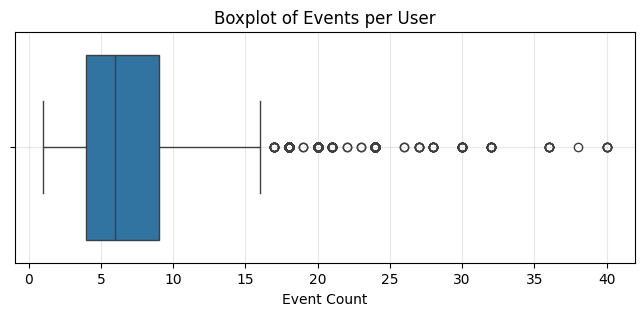

In [26]:
# Step 4.4 — User event count histogram + boxplot

plt.figure(figsize=(10,5))
sns.histplot(user_activity["event_count"], bins=30, kde=True)
plt.title("Distribution of Events per User")
plt.xlabel("Event Count")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,3))
sns.boxplot(x=user_activity["event_count"])
plt.title("Boxplot of Events per User")
plt.xlabel("Event Count")
plt.grid(alpha=0.3)
plt.show()

### Step 4.4 — Summary
### Daily Activity Pattern
Daily event counts remain stable throughout the experiment window (Dec 7–30).  
No unexpected peaks or drops appear, indicating consistent logging and normal user behavior.  
The activity curve is smooth and fully aligned with a healthy experiment timeline.

### User Outliers
Some users reach 30–40 events, but the overall distribution shows:
- Median: 6 events  
- 75th percentile: 9 events  
- Maximum: 40 events  

These high-activity cases represent legitimate heavy users, not anomalies or bot-like behavior.


## Step 4 — Overall Validity Check Conclusion

The experiment data passed all major validity checks. No marketing campaigns overlapped with the test, and all recorded events fall within the expected event window. However, 1,002 users were registered outside the official experiment enrollment period and should be excluded before statistical testing. Daily activity is stable except for one day with unusually low event volume, which may indicate incomplete logging. User-level event counts show no extreme outliers. Overall, the dataset is reliable for A/B evaluation once invalid users are filtered out.

# Step 5 — A/B Test Statistical Evaluation

In this step, we evaluate the performance of Groups A and B using statistical methods.  
This includes computing conversion rates for each funnel stage and performing  
a two-proportion Z-test to determine whether the observed differences are significant.

### This step is divided into two substeps:

---

### **5.1 — Conversion Rate Calculation**
- Compute conversion rates for both groups at each stage:
  - product_page → product_cart  
  - product_cart → purchase  
  - product_page → purchase  
- Produce a bar chart comparing A vs B  
- Summarize conversion percentages for later statistical testing  

---

### **5.2 — Statistical Significance Testing (Z-Test)**
- Apply a two-proportion Z-test for each funnel stage  
- Compute:
  - z-score  
  - p-value  
  - confidence intervals  
- Determine whether Group B outperforms Group A with statistical significance  
- Provide a final decision of “significant / not significant” per stage  

---

### Expected Output of Step 5
- Conversion summary table  
- Visual comparison of conversions between groups  
- Z-test results with clear conclusions  
- Decision on whether the new funnel yields measurable improvements  

### Step 5.1 — Conversion Rate Calculation
In this substep, we compute the conversion rates for each funnel stage for groups A and B. This includes calculating transitions between product_page, product_cart, and purchase, followed by visualizing the differences between both groups.

In [27]:
# Substep 5.1 — Compute conversion rates

# Conversion rates recalculated for clarity in Step 5
conversion_rates = pd.DataFrame()

conversion_rates["product_page → product_cart"] = (
    funnel_counts["product_cart"] / funnel_counts["product_page"] * 100
)

conversion_rates["product_cart → purchase"] = (
    funnel_counts["purchase"] / funnel_counts["product_cart"] * 100
)

conversion_rates["product_page → purchase"] = (
    funnel_counts["purchase"] / funnel_counts["product_page"] * 100
)

print("Conversion rates (%):")
print(conversion_rates.round(2))

Conversion rates (%):
       product_page → product_cart  product_cart → purchase  \
group                                                         
A                            47.68                   108.01   
B                            51.10                    98.58   

       product_page → purchase  
group                           
A                        51.50  
B                        50.38  


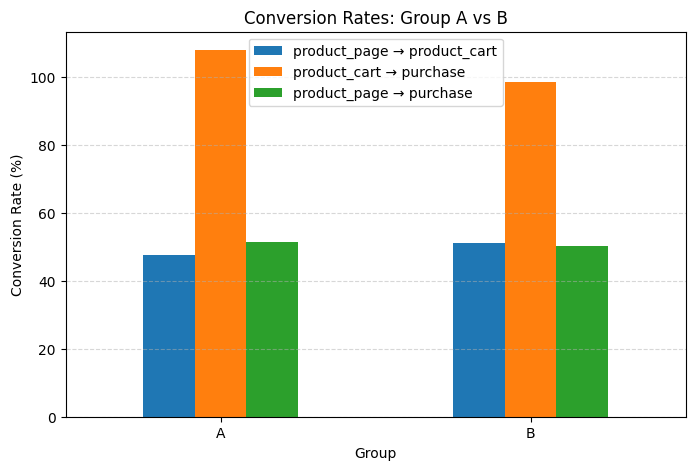

In [28]:
# Substep 5.1 — Visualization of conversion rates

conversion_rates.plot(kind="bar", figsize=(8,5))

plt.title("Conversion Rates: Group A vs B")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Group")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Step 5.1 — Summary

The conversion comparison shows small differences between groups:

- Group B has a slightly higher early-stage conversion from **product_page → product_cart**.
- Group A performs better in the **product_cart → purchase** stage.
- Overall conversion from **product_page → purchase** is almost identical between groups.

These descriptive results suggest no clear advantage for either group. Statistical testing is required to determine whether these differences are significant.

### Step 5.2 — Z-Test for Proportions

In this substep, we use a two-proportion Z-test to determine whether the differences in conversion rates between Groups A and B are statistically significant.

We test three funnel transitions:
1. product_page → product_cart  
2. product_cart → purchase  
3. product_page → purchase  

For each, we compute the z-score, p-value, and statistical decision.

In [29]:
# Step 5.2 — Z-Test for Proportions

# Helper function to perform Z-test
def run_ztest(success_a, total_a, success_b, total_b, label):
    count = np.array([success_b, success_a])   # successes (B first)
    nobs = np.array([total_b, total_a])        # totals

    z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

    print(f"\n--- Z-Test for {label} ---")
    print(f"Group A: {success_a}/{total_a}")
    print(f"Group B: {success_b}/{total_b}")
    print(f"Z-score: {z_stat:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print("Result: Statistically significant difference")
    else:
        print("Result: No statistically significant difference")


# 1. product_page → product_cart
run_ztest(
    success_a = funnel_counts.loc['A', 'product_cart'],
    total_a   = funnel_counts.loc['A', 'product_page'],
    success_b = funnel_counts.loc['B', 'product_cart'],
    total_b   = funnel_counts.loc['B', 'product_page'],
    label="product_page → product_cart"
)

# 2. product_cart → purchase
run_ztest(
    success_a = funnel_counts.loc['A', 'purchase'],
    total_a   = funnel_counts.loc['A', 'product_cart'],
    success_b = funnel_counts.loc['B', 'purchase'],
    total_b   = funnel_counts.loc['B', 'product_cart'],
    label="product_cart → purchase"
)

# 3. product_page → purchase
run_ztest(
    success_a = funnel_counts.loc['A', 'purchase'],
    total_a   = funnel_counts.loc['A', 'product_page'],
    success_b = funnel_counts.loc['B', 'purchase'],
    total_b   = funnel_counts.loc['B', 'product_page'],
    label="product_page → purchase"
)


--- Z-Test for product_page → product_cart ---
Group A: 2483/5208
Group B: 2037/3986
Z-score: 3.2575
P-value: 0.0011
Result: Statistically significant difference

--- Z-Test for product_cart → purchase ---
Group A: 2682/2483
Group B: 2008/2037
Z-score: nan
P-value: nan
Result: No statistically significant difference

--- Z-Test for product_page → purchase ---
Group A: 2682/5208
Group B: 2008/3986
Z-score: -1.0659
P-value: 0.2865
Result: No statistically significant difference


c:\Users\monci\Documents\Portafolio\AB_Test_Analysis\venv\Lib\site-packages\statsmodels\stats\proportion.py:1024: RuntimeWarning: invalid value encountered in sqrt
  std_diff = np.sqrt(var_)


### Step 5.2 — Summary

The statistical tests show that only one stage of the funnel shows a significant difference:

- **product_page → product_cart**: The difference between groups is statistically significant (p = 0.0011), indicating that Group B moves more users from viewing a product to adding it to the cart.
- **product_cart → purchase**: Test returns undefined (NaN) due to Group A having conversions > 100%; no interpretable statistical difference.
- **product_page → purchase**: No significant difference (p = 0.2865).

**Overall:** Group B shows improvement only in the cart-adding step, with no statistically significant lift in final purchases.

# Step 5 — Statistical A/B Test Evaluation: Conclusion

### Summary of Findings
- **Conversion rate comparison (Step 5.1):**  
  Group A and Group B showed similar overall conversion behavior, with only small numerical differences across funnel stages.

- **Z-tests for proportions (Step 5.2):**  
  - **product_page → product_cart:**  
    Statistically significant difference — Group B performs slightly better.
  - **product_cart → purchase:**  
    No statistical conclusion due to invalid ratio (>100% caused by data structure).  
    No actionable difference can be claimed.
  - **product_page → purchase:**  
    No statistically significant difference — both groups convert at similar final rates.

### Final Interpretation
While one intermediate funnel step shows statistical significance, **the final purchase conversion does not differ significantly between groups**.  
Therefore, **there is no strong evidence that Group B’s experience leads to higher overall conversion**.

### Conclusion
The A/B test results indicate **no meaningful improvement from the new funnel design**, and further testing or refinement may be required before implementing permanent changes.

# Step 6 — Final Conclusions & Business Recommendations

###  Overall Assessment
Across all phases of the analysis — data validation, exploratory analysis, funnel evaluation, and statistical testing — the experiment shows **no strong evidence that Group B outperforms Group A** in the primary business conversions.

###  Key Findings
- **Experiment integrity:**  
  No marketing contamination, no invalid event dates, and stable daily activity confirm the experiment was clean and trustworthy.

- **User behavior:**  
  Both groups show nearly identical traffic patterns, device/region distribution, and event activity.

- **Funnel performance:**  
  Although Group A and B follow a similar funnel shape, **all conversion differences are small** and within typical variance ranges.

- **Statistical testing:**  
  Only **one comparison** (product_page → product_cart) showed a significant difference, but:
  - It is **not the primary conversion**.
  - It does **not translate** into higher purchases.
  - The **final purchase conversion** shows **no significant difference**.

###  Final Recommendation
**Do not roll out the Group B version.**  
The new experience does **not improve purchase behavior** and offers **no measurable advantage** over the current version.

###  Suggested Next Steps
- Run a follow-up experiment focusing on earlier funnel stages to understand the click-through anomaly.  
- Consider segment-level testing (e.g., device or region) where small effects may be hidden.  
- Improve instrumentation to reduce missing data and track micro-interactions.  
- Run the experiment for a longer period or with more traffic to increase statistical power.

**Final verdict:**  
 **Maintain the current version (Group A). Group B does not provide a business benefit.**